# **RoadSafeAI: Traffic Accident Severity Prdiction System**

1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import pickle

2. Loading dataset

In [2]:
df = pd.read_csv(
    "/content/Addis_Ababa_city_RTA.csv"
)

print(df.head())
print(df.shape)

       Time Day_of_week Age_band_of_driver Drivers_gender   Educational_level  \
0  17:02:00      Monday              18-30           Male   Above high school   
1  17:02:00      Monday              31-50           Male  Junior high school   
2  17:02:00      Monday              18-30           Male  Junior high school   
3   1:06:00      Sunday              18-30           Male  Junior high school   
4   1:06:00      Sunday              18-30           Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr                  NaN   

  Owner_of_vehicle Service_year_of_vehicle  ... Number_of_casualties  \
0            Owner        

3. Data Cleaning

In [3]:
df.drop(
    columns=[
        "Time",
        "Accident_ID"
    ],
    inplace=True,
    errors="ignore"
)

df = df.dropna()

4. Defining features and target

In [4]:
X = df.drop(
    "Accident_severity",
    axis=1
)


y = df["Accident_severity"]

5. Saving and encoding the target

In [6]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

pickle.dump(
    target_encoder,
    open(
        "target_encoder.pkl",
        "wb"
    )
)

6. Identify the columns

In [7]:
cat_cols = X.select_dtypes(
    include="object"
).columns


num_cols = X.select_dtypes(
    exclude="object"
).columns

7. Preprocessing

In [8]:
preprocessor = ColumnTransformer(

[
(
"cat",
OneHotEncoder(
handle_unknown="ignore"
),
cat_cols
)

],

remainder="passthrough"

)

8. Train Test Split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

9. XGBoost Model

In [10]:
model = XGBClassifier(

n_estimators=300,

learning_rate=0.05,

max_depth=5,

subsample=0.8,

colsample_bytree=0.8,

random_state=42

)

10. Creating Pipeline

In [11]:
pipeline = Pipeline(

steps=[

(
"preprocessor",
preprocessor
),

(
"model",
model
)

]

)

12. Model Training

In [12]:
pipeline.fit(

X_train,

y_train

)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day_of_week', 'Age_band_of_driver', 'Drivers_gender',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_a...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

13. Prediction

In [13]:
pred = pipeline.predict(
    X_test
)

14. Evaluation

In [14]:
print(
accuracy_score(
y_test,
pred
)
)


print(
classification_report(
y_test,
pred
)
)

0.8394886363636364
              precision    recall  f1-score   support

           0       0.14      0.05      0.07        20
           1       0.75      0.09      0.17        96
           2       0.85      0.99      0.91       588

    accuracy                           0.84       704
   macro avg       0.58      0.38      0.38       704
weighted avg       0.81      0.84      0.79       704



16. Confusion Matrix

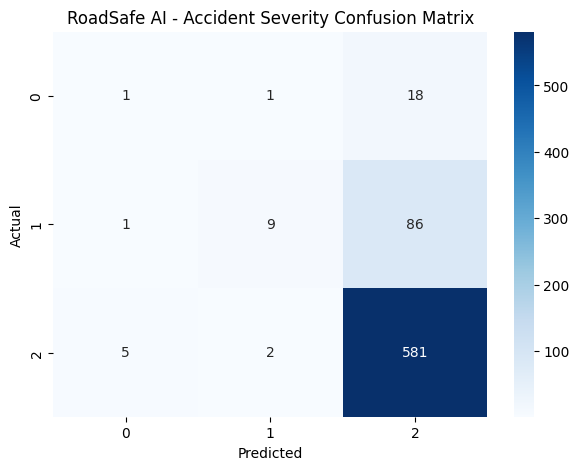

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(
    y_test,
    pred
)


plt.figure(figsize=(7,5))


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "RoadSafe AI - Accident Severity Confusion Matrix"
)


plt.show()

15. Saving the model

In [15]:
pickle.dump(

pipeline,

open(

"accident_model.pkl",

"wb"

)

)

Model Accuracy: ~ 84%